<a href="https://colab.research.google.com/github/Nivethanajacob/Calculator/blob/main/Mind_Check_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers accelerate datasets -q
print(' Done')

 Done


# **Libraries**

In [ ]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import joblib

from sklearn.preprocessing      import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection    import train_test_split
from sklearn.metrics            import (
    accuracy_score, f1_score,
    classification_report,
    ConfusionMatrixDisplay, confusion_matrix
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoConfig,
    Trainer, TrainingArguments, EarlyStoppingCallback,
    DataCollatorWithPadding, set_seed,
)

warnings.filterwarnings('ignore')
set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Imports OK — device: {device}')
if device.type == 'cpu':
    print('No GPU detected. Go to Runtime → Change runtime type → GPU')

Imports OK — device: cuda


In [ ]:
FINE_EMOTIONS = [
    'admiration','amusement','anger','annoyance','approval','caring',
    'confusion','curiosity','desire','disappointment','disapproval',
    'disgust','embarrassment','excitement','fear','gratitude','grief',
    'joy','love','nervousness','optimism','pride','realization',
    'relief','remorse','sadness','surprise','neutral'
]

# 7 grouped emotion classes
GROUPS = {
    'joy_excitement':   ['joy','amusement','excitement','pride','optimism','relief'],
    'affection':        ['love','admiration','caring','gratitude','approval'],
    'anger_disgust':    ['anger','annoyance','disapproval','disgust'],
    'sadness_grief':    ['sadness','grief','disappointment','remorse'],
    'fear_nervousness': ['fear','nervousness','embarrassment'],
    'cognitive':        ['confusion','curiosity','realization','surprise'],
    'neutral':          ['neutral'],
}
ALL_CLASSES = list(GROUPS.keys())

# SamLowe/roberta-base-go_emotions is already pretrained on GoEmotions
MODEL_NAME  = 'SamLowe/roberta-base-go_emotions'
MAX_SEQ_LEN = 128

print(f' {len(ALL_CLASSES)} classes: {ALL_CLASSES}')
print(f' Model: {MODEL_NAME}')

 7 classes: ['joy_excitement', 'affection', 'anger_disgust', 'sadness_grief', 'fear_nervousness', 'cognitive', 'neutral']
 Model: SamLowe/roberta-base-go_emotions


# **Load DataSet**

In [ ]:
df = pd.read_csv('/content/goemotions_full.csv')
print(f'Raw rows   : {len(df):,}')
print(f'Columns    : {df.shape[1]}')
print(f'Null values: {df.isnull().sum().sum()}')
print(f'Duplicates : {df.duplicated().sum()}')
df.head()

Raw rows   : 211,225
Columns    : 37
Null values: 0
Duplicates : 0


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


# **EDA**

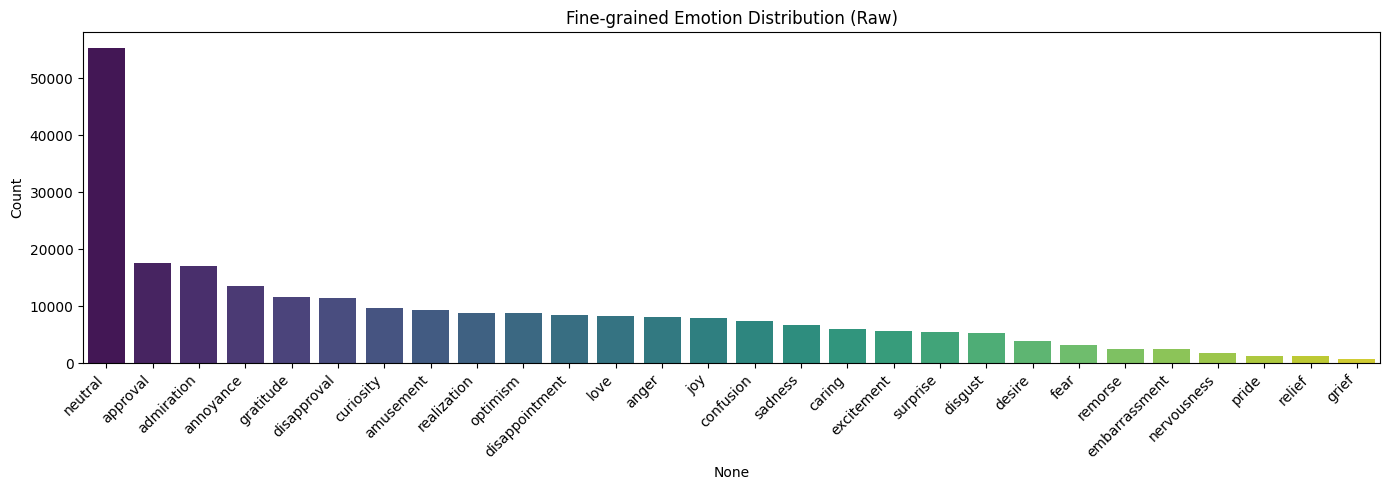

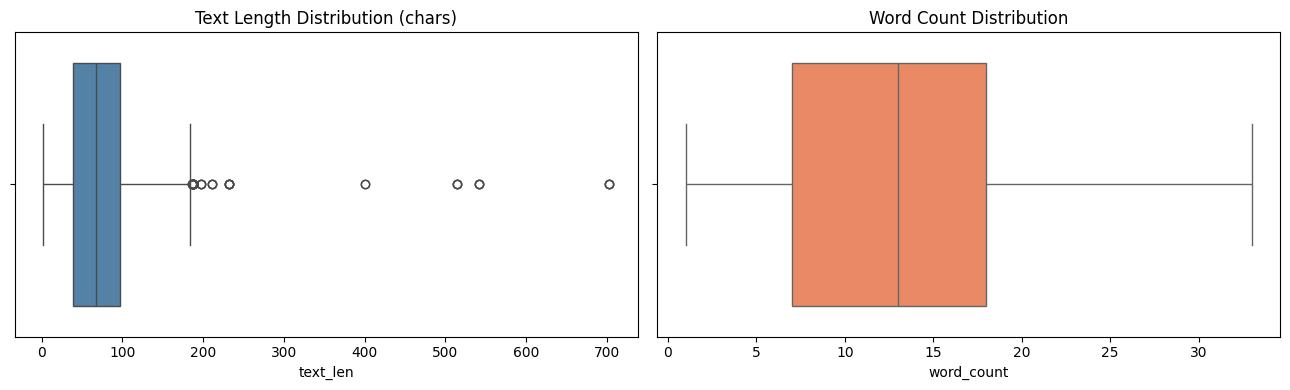

count    211225.0
mean         69.3
std          36.5
min           2.0
25%          39.0
50%          67.0
75%          97.0
max         703.0
Name: text_len, dtype: float64

Avg emotions per text: 1.18


In [ ]:
# Fine-grained emotion distribution
emotion_counts = df[FINE_EMOTIONS].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Fine-grained Emotion Distribution (Raw)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Text length
df['text_len']  = df['text'].astype(str).apply(len)
df['word_count']= df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x=df['text_len'],   ax=axes[0], color='steelblue')
axes[0].set_title('Text Length Distribution (chars)')
sns.boxplot(x=df['word_count'], ax=axes[1], color='coral')
axes[1].set_title('Word Count Distribution')
plt.tight_layout()
plt.show()

print(df['text_len'].describe().round(1))

df['emotion_count'] = df[FINE_EMOTIONS].sum(axis=1)
print(f'\nAvg emotions per text: {df["emotion_count"].mean():.2f}')

# **Data Cleaning**

In [ ]:
df = df[df['text'].notnull()]
df = df[df['text'].str.strip() != '']
df = df[df['example_very_unclear'] == False]
df = df[(df['text_len'] > 5) & (df['text_len'] < 250)]
print(f'After filters: {len(df):,}')

CONTRACTIONS = {
    "won't":"will not","can't":"cannot","don't":"do not",
    "doesn't":"does not","didn't":"did not","isn't":"is not",
    "aren't":"are not","wasn't":"was not","weren't":"were not",
    "haven't":"have not","hasn't":"has not","hadn't":"had not",
    "wouldn't":"would not","shouldn't":"should not","couldn't":"could not",
    "i'm":"i am","i've":"i have","i'll":"i will","i'd":"i would",
    "you're":"you are","you've":"you have","you'll":"you will",
    "he's":"he is","she's":"she is","it's":"it is",
    "we're":"we are","we've":"we have","they're":"they are",
    "they've":"they have","that's":"that is","there's":"there is",
    "what's":"what is","let's":"let us",
}

def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)         # remove URLs
    text = re.sub(r'\S+@\S+\.\S+', '', text)                  # remove emails
    text = re.sub(r'\[.*?\]', '', text)                        # remove [deleted], [removed] etc.
    text = re.sub(r'r/\w+|u/\w+', '', text)                   # remove Reddit handles
    for c, e in CONTRACTIONS.items():
        text = text.replace(c, e)                              # expand contractions
    text = re.sub(r'[^\w\s!?]', ' ', text)                    # strip special chars, keep !?
    text = re.sub(r'!{2,}', '!!', text)                       # normalize !!! → !!
    text = re.sub(r'\?{2,}', '??', text)                      # normalize ??? → ??
    text = re.sub(r'(\w)\1{2,}', r'\1\1', text)               # sooooo → soo
    text = re.sub(r'\b\d+\b', '', text)                        # remove standalone numbers
    text = re.sub(r'\s+', ' ', text).strip()                   # collapse whitespace
    return text

df['text'] = df['text'].apply(clean_text)
df = df[df['text'].str.len() >= 5]                             # drop anything that became empty
df = df[df['text'].str.split().str.len() >= 2]                 # at least 2 words
df = df.reset_index(drop=True)
print(f'After cleaning: {len(df):,}')

After filters: 207,689
After cleaning: 206,828


## **Grouping Emotion**

In [ ]:
# Aggregate multiple rater rows into one per unique text
df_agg = df.groupby('text')[FINE_EMOTIONS].max().reset_index()
print(f'After aggregation: {len(df_agg):,} unique texts')

# Score each group = sum of fine-grained labels in that group
for group, fine_list in GROUPS.items():
    cols = [f for f in fine_list if f in df_agg.columns]
    df_agg[group] = df_agg[cols].sum(axis=1)

# Pick group with highest annotation evidence, BUT discard ambiguous ties
def get_unambiguous_emotion(row):
    scores = {g: row[g] for g in ALL_CLASSES}
    max_score = max(scores.values())

    if max_score == 0:
        return 'neutral'

    # Find how many groups share the maximum score
    top_groups = [g for g, v in scores.items() if v == max_score]

    # If there is a clear winner, return it. If tied, mark as ambiguous.
    if len(top_groups) == 1:
        return top_groups[0]
    else:
        return 'ambiguous'

df_agg['emotion'] = df_agg.apply(get_unambiguous_emotion, axis=1)

total         = len(df_agg)
ambig_count   = (df_agg['emotion'] == 'ambiguous').sum()
ambig_pct     = ambig_count / total * 100
print(f'Ambiguous rows dropped: {ambig_count:,} / {total:,} ({ambig_pct:.1f}%)')

df_final = df_agg[df_agg['emotion'] != 'ambiguous'][['text','emotion']].copy()
df_final = df_final[df_final['text'].str.strip() != ''].dropna().reset_index(drop=True)

print(f'\nFinal dataset (after dropping ties): {len(df_final):,} rows')

After aggregation: 57,091 unique texts
Ambiguous rows dropped: 26,557 / 57,091 (46.5%)

Final dataset (after dropping ties): 30,534 rows


## **Load Secondary DataSet**

In [ ]:
from datasets import load_dataset

print(f"GoEmotions rows before merge: {len(df_final):,}")

# Load the Hugging Face dataset
hf_dataset = load_dataset("dair-ai/emotion", "split")
df_extra = pd.concat([
    hf_dataset['train'].to_pandas(),
    hf_dataset['validation'].to_pandas(),
    hf_dataset['test'].to_pandas()
], ignore_index=True)

hf_label_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}
df_extra['emotion_str'] = df_extra['label'].map(hf_label_map)

group_mapping = {
    'joy':      'joy_excitement',
    'love':     'affection',
    'anger':    'anger_disgust',
    'sadness':  'sadness_grief',
    'fear':     'fear_nervousness',
    'surprise': 'joy_excitement'
}
df_extra['emotion'] = df_extra['emotion_str'].map(group_mapping)

# Drop the old columns to match df_final structure ('text' and 'emotion')
df_extra = df_extra[['text', 'emotion']]

# Clean the new text using the exact same function you used for GoEmotions
df_extra['text'] = df_extra['text'].apply(clean_text)
df_extra = df_extra[df_extra['text'].str.split().str.len() >= 2]

# Concatenate both datasets together
df_final = pd.concat([df_final, df_extra], ignore_index=True)

# Drop any accidental duplicates that might exist across datasets
df_final = df_final.drop_duplicates(subset=['text']).reset_index(drop=True)

print(f"External dataset rows added : {len(df_extra):,}")
print(f"Merged final dataset size   : {len(df_final):,} rows")

GoEmotions rows before merge: 30,534


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

External dataset rows added : 20,000
Merged final dataset size   : 50,482 rows


## **Emotion Count & Visualization**

                  count  percent
emotion                         
joy_excitement    11551     22.9
affection         10442     20.7
anger_disgust      9101     18.0
sadness_grief      8012     15.9
neutral            4362      8.6
cognitive          3994      7.9
fear_nervousness   3020      6.0


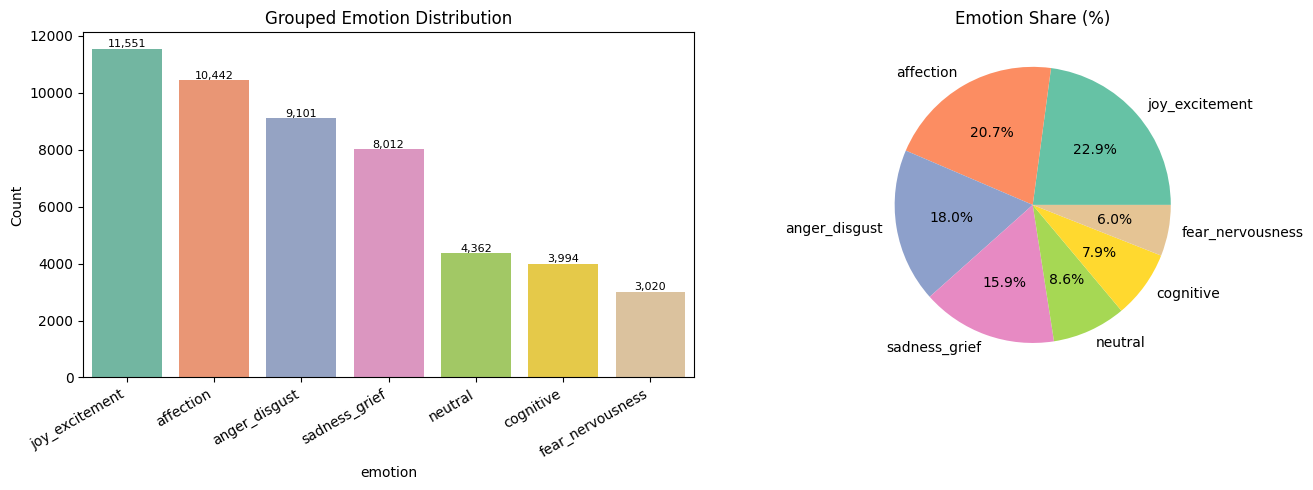

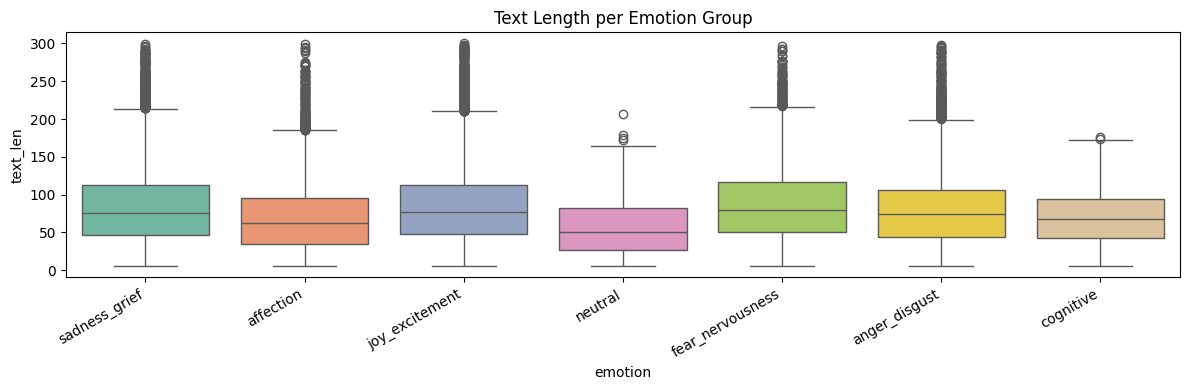

In [ ]:
counts = df_final['emotion'].value_counts()
pct    = (counts / len(df_final) * 100).round(1)
print(pd.DataFrame({'count': counts, 'percent': pct}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=counts.index, y=counts.values, palette='Set2', ax=axes[0])
axes[0].set_title('Grouped Emotion Distribution')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 50,
                 f'{int(p.get_height()):,}', ha='center', fontsize=8)

axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2', len(counts)))
axes[1].set_title('Emotion Share (%)')
plt.tight_layout()
plt.show()

df_final['text_len'] = df_final['text'].apply(len)
plt.figure(figsize=(12, 4))
sns.boxplot(x='emotion', y='text_len', data=df_final, palette='Set2')
plt.title('Text Length per Emotion Group')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## **Encoding - LabelEncoder()**

In [ ]:
le = LabelEncoder()
df_final['label'] = le.fit_transform(df_final['emotion'])
num_labels        = len(le.classes_)

print(f'Classes ({num_labels}):')
for i, name in enumerate(le.classes_):
    print(f'  {i}  →  {name}')




Classes (7):
  0  →  affection
  1  →  anger_disgust
  2  →  cognitive
  3  →  fear_nervousness
  4  →  joy_excitement
  5  →  neutral
  6  →  sadness_grief


# **Train -Test Split**

In [ ]:
X = df_final['text'].values
y = df_final['label'].values

# 70 / 15 / 15 stratified split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Train: 35,357 | Val: 7,552 | Test: 7,573


In [ ]:
# Upsample rare classes to minimum 400 samples in training set
MIN_SAMPLES_RARE = 400
X_train_list, y_train_list = list(X_train), list(y_train)

for cls_idx in np.unique(y_train):
    cls_mask    = np.where(y_train == cls_idx)[0]
    n_available = len(cls_mask)
    if n_available < MIN_SAMPLES_RARE:
        n_needed     = MIN_SAMPLES_RARE - n_available
        upsample_idx = np.random.choice(cls_mask, size=n_needed, replace=True)
        X_train_list.extend(X_train[upsample_idx])
        y_train_list.extend(y_train[upsample_idx])
        print(f'  Upsampled {le.classes_[cls_idx]}: {n_available} → {MIN_SAMPLES_RARE}')

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

# Shuffle after upsampling
shuffle_idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[shuffle_idx], y_train[shuffle_idx]

print(f'\nAfter upsampling — Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')


After upsampling — Train: 35,357 | Val: 7,552 | Test: 7,573


# **Deep Learning**

In [ ]:
# AutoTokenizer
# — understands word meaning, context, casing, punctuation
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Lazy tokenization — tokenize one sample at a time to avoid OOM
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc  = tokenizer(self.texts[idx], truncation=True, max_length=MAX_SEQ_LEN)
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = EmotionDataset(X_train, y_train)
val_dataset   = EmotionDataset(X_val,   y_val)
test_dataset  = EmotionDataset(X_test,  y_test)

# WeightedRandomSampler — rare classes seen as often as common ones
label_counts   = np.bincount(y_train, minlength=num_labels).astype(float)
class_w        = 1.0 / (label_counts + 1e-6)
sample_weights = torch.tensor([class_w[l] for l in y_train], dtype=torch.float)
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Pads each batch to its longest sequence — faster than padding to max_length=128
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f' Tokenizer loaded: {MODEL_NAME}')
print(f'   Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}')
print(f'   WeightedRandomSampler ready — {num_labels} class weights applied')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

 Tokenizer loaded: SamLowe/roberta-base-go_emotions
   Train: 35,357 | Val: 7,552 | Test: 7,573
   WeightedRandomSampler ready — 7 class weights applied


In [ ]:
config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels   = num_labels,
    problem_type = 'single_label_classification'
)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, config=config, ignore_mismatched_sizes=True
).to(device)
print(f' Loaded {MODEL_NAME}')
print(f'   Output classes: {num_labels}')
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'   Parameters    : {total_params:.1f}M')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |                                                                                      
--------------------------------+------------+--------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                      
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([28, 768]) vs model:torch.Size([7, 768])
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([28]) vs model:torch.Size([7])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


 Loaded SamLowe/roberta-base-go_emotions
   Output classes: 7
   Parameters    : 124.7M


In [ ]:
import torch.nn.functional as F

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'f1_micro': f1_score(labels, preds, average='micro', zero_division=0),
    }

# Apply Square Root Smoothing to weights so minority classes aren't over-represented
raw_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
smoothed_weights = np.sqrt(raw_weights)
alpha_tensor = torch.tensor(smoothed_weights, dtype=torch.float32).to(device)

print('Smoothed Class weights (Alpha):')
for i, (cls, w) in enumerate(zip(le.classes_, smoothed_weights)):
    print(f'  {cls:20s}: {w:.3f}')

class FocalLossTrainer(Trainer):
    def __init__(self, *args, alpha=None, gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.gamma = gamma

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Calculate standard cross entropy (unreduced)
        ce_loss = F.cross_entropy(logits, labels, reduction='none')

        # Calculate probabilities of the correct class
        pt = torch.exp(-ce_loss)

        # Focal Loss formula
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        # Apply smoothed class weights
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.dtype)[labels]
            focal_loss = alpha_t * focal_loss

        loss = focal_loss.mean()
        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size  = self.args.per_device_train_batch_size,
            sampler     = sampler,
            collate_fn  = self.data_collator,
            drop_last   = self.args.dataloader_drop_last,
            num_workers = self.args.dataloader_num_workers,
            pin_memory  = self.args.dataloader_pin_memory,
        )

Smoothed Class weights (Alpha):
  affection           : 0.831
  anger_disgust       : 0.890
  cognitive           : 1.344
  fear_nervousness    : 1.545
  joy_excitement      : 0.790
  neutral             : 1.286
  sadness_grief       : 0.949


## **Training**

In [ ]:
training_args = TrainingArguments(
    output_dir                  = './roberta_results',
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    gradient_accumulation_steps = 1,
    learning_rate               = 2e-5,
    warmup_steps                = 66,
    weight_decay                = 0.01,
    lr_scheduler_type           = 'cosine',
    max_grad_norm               = 1.0,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_steps               = 50,
    bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16 = torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    seed                        = 42,
    save_total_limit            = 2,
    report_to                   = 'none',
)

# Initialize the new FocalLossTrainer
trainer = FocalLossTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    data_collator   = data_collator,
    alpha           = alpha_tensor,
    gamma           = 2.0,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro
1,0.069131,0.390173,0.785355,0.765367,0.785355
2,0.034372,0.449740,0.780191,0.756213,0.780191
3,0.049525,0.429142,0.783501,0.765873,0.783501
4,0.071321,0.400371,0.787209,0.768608,0.787209
5,0.038553,0.424943,0.795551,0.777087,0.795551
6,0.028268,0.437311,0.795683,0.776945,0.795683
7,0.023928,0.454746,0.792903,0.772671,0.792903


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=7735, training_loss=0.051849840083427405, metrics={'train_runtime': 3129.9057, 'train_samples_per_second': 79.076, 'train_steps_per_second': 2.471, 'total_flos': 5562026325690150.0, 'train_loss': 0.051849840083427405, 'epoch': 7.0})

# **Evaluation**

In [ ]:
results = trainer.evaluate(test_dataset)

print('=' * 55)
print(f'  Test Accuracy : {results["eval_accuracy"]:.4f}')
print(f'  Test Macro F1 : {results["eval_f1_macro"]:.4f}')
print(f'  Test Micro F1 : {results["eval_f1_micro"]:.4f}')
print('=' * 55)

preds_out = trainer.predict(test_dataset)
y_pred    = np.argmax(preds_out.predictions, axis=1)

print('\nClassification Report:')
print(classification_report(y_test, y_pred,
                              target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues'
)
ax.set_title('RoBERTa — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score
per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

plt.figure(figsize=(10, 4))
bars = plt.bar(le.classes_, per_class_f1, color=sns.color_palette('Set2', len(le.classes_)))
plt.title('Per-Class F1 Score — RoBERTa')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Per-class F1:')
for cls, f1 in zip(le.classes_, per_class_f1):
    bar = '█' * int(f1 * 30)
    print(f'  {cls:20s} {f1:.3f}  {bar}')

In [ ]:
model.eval()

def predict_emotion(text: str) -> dict:
    """Predict emotion for a single text string."""
    text = clean_text(text)
    inputs = tokenizer(text, return_tensors='pt',
                       truncation=True, max_length=MAX_SEQ_LEN)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs    = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred_idx = int(np.argmax(probs))
    top3     = sorted(zip(le.classes_, probs), key=lambda x: -x[1])[:3]
    return {
        'emotion':    le.inverse_transform([pred_idx])[0],
        'confidence': round(float(probs[pred_idx]), 4),
        'top3':       {k: round(float(v), 4) for k, v in top3},
    }

test_sentences = [
    "I just got promoted, I can't believe it!",
    "Everything feels so pointless lately.",
    "Why would anyone do something like that??",
    "I feel so scared and nervous about tomorrow.",
    "I love how caring and kind you are.",
    "I AM SO DONE WITH THIS!!!",
    "Not sure what to think, this is all so confusing.",
    "I'm grateful for everything you've done for me.",
]

print('Inference results:\n')
for s in test_sentences:
    r = predict_emotion(s)
    print(f"  Text      : '{s}'")
    print(f"  Emotion   : {r['emotion']}  ({r['confidence']:.1%} confidence)")
    print(f"  Top 3     : {r['top3']}\n")

In [ ]:
model.save_pretrained('./saved_roberta')
tokenizer.save_pretrained('./saved_roberta')
joblib.dump(le, 'label_encoder.pkl')

df_final[['text','emotion']].to_csv('grouped_emotions_dataset.csv', index=False)

print(f'\nClasses: {list(le.classes_)}')
